# Шапка

ДР1. Группа 11. Sem2
- Руденко Евгений Александрович
- Сажин Семён Михайлович
- Тихомиров Алексей Константинович

## 0. Подготовка

**Признак (feature)** — число, которым модель описывает текст.
Например, это может быть количество употреблений слова.

**Классификатор** — алгоритм, который учится по примерам с известными
классами, а затем предсказывает класс нового текста.

**Macro F1** — итоговая оценка от 0 до 1. Она отдельно измеряет
качество для каждого класса, а затем усредняет результаты. Чем ближе
значение к 1, тем лучше модель одинаково справляется со всеми классами.

In [1]:
import copy
import importlib.util
import random
import re
import subprocess
import sys
import time
import warnings
from collections import Counter
from functools import lru_cache
from math import log2
from pathlib import Path
from string import punctuation

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_extraction.text import (
    CountVectorizer,
    HashingVectorizer,
    TfidfVectorizer,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# В Colab устанавливаем только недостающие библиотеки лемматизации.
required_packages = {
    "pymorphy3": "pymorphy3",
    "pymystem3": "pymystem3",
    "natasha": "natasha",
}
missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]
if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", *missing_packages]
    )

from natasha import Doc, MorphVocab, NewsEmbedding, NewsMorphTagger, Segmenter
from pymorphy3 import MorphAnalyzer
from pymystem3 import Mystem

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_colwidth", 90)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings(
    "ignore", message="pkg_resources is deprecated.*"
)

In [2]:
# Ищем CSV сначала в текущей папке, затем в локальной папке данных.
dataset_candidates = [
    Path("resumes_ru_6000_labeled.csv"),
    Path("../output/resumes_ru_6000_labeled.csv"),
    Path("output/resumes_ru_6000_labeled.csv"),
]
dataset_path = next(
    (path for path in dataset_candidates if path.exists()),
    None,
)

if dataset_path is None:
    raise FileNotFoundError(
        "Не найден наш размеченный датасет. Загрузите CSV в рабочую папку."
    )

df = pd.read_csv(dataset_path)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбца")
display(df.head(3))

Размер датасета: 6000 строк, 3 столбца


,index,text,class
0,1,"Проведение инвентаризаций товаров продуктового магазина, подготовка и анализ инвентари...",Образование и наука
1,2,"работоспособность, способность к длительной однообразной деятельности, знание специаль...",Финансы и бухгалтерия
2,3,"Работа в стационаре + работа в поликлинике!\nчеловек.\nПлановые, экстренные операции п...",Медицина и здравоохранение


In [3]:
# Сводка помогает понять структуру и качество исходных данных до обучения моделей.
data_overview = pd.DataFrame(
    {
        "Показатель": [
            "Количество строк",
            "Уникальные тексты",
            "Пропуски в текстах",
            "Количество классов",
        ],
        "Значение": [
            len(df),
            df["text"].nunique(),
            int(df["text"].isna().sum()),
            df["class"].nunique(),
        ],
    }
)
display(data_overview)

class_counts = df["class"].value_counts().sort_index()
display(class_counts.rename("Количество резюме").to_frame())

,Показатель,Значение
0,Количество строк,6000
1,Уникальные тексты,6000
2,Пропуски в текстах,0
3,Количество классов,6


,Количество резюме
class,
Медицина и здравоохранение,1000
Образование и наука,1000
Строительство и ремонт,1000
Торговля и продажи,1000
Транспорт и логистика,1000
Финансы и бухгалтерия,1000


Набор сбалансирован: в каждом классе одинаковое количество резюме.

- **Обучающая выборка (70%)** — модель видит её и учится.
- **Тестовая выборка (30%)** — используется для проверки претендента на новый рекорд.
- **Validation** — отдельная часть обучающей выборки для честного сравнения моделей.

Все главы используют одну validation-часть. Новый validation-рекорд проверяется
на тесте и становится лидером только после обновления Test Macro F1.

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    df["text"], df["class"], test_size=0.30,
    random_state=RANDOM_STATE, stratify=df["class"]
)
x_model_fit, x_model_valid, y_model_fit, y_model_valid = train_test_split(
    x_train, y_train, test_size=0.20,
    random_state=RANDOM_STATE, stratify=y_train
)

best_validation_f1 = -np.inf
best_test_f1 = -np.inf
best_model_name = None
best_model_strategy = None
best_model_validation_f1 = -np.inf
record_rows = []


def is_record_candidate(validation_f1):
    """Проверяет, превзошла ли модель общий рекорд на валидации."""
    return validation_f1 > best_validation_f1 + 1e-12


def register_tested_candidate(model_name, strategy, validation_f1, test_f1):
    """Обновляет рекорды и печатает краткий результат сравнения."""
    global best_validation_f1, best_test_f1
    global best_model_name, best_model_strategy, best_model_validation_f1
    if not is_record_candidate(validation_f1):
        return False
    best_validation_f1 = validation_f1
    is_new_test_record = test_f1 > best_test_f1 + 1e-12
    if is_new_test_record:
        best_test_f1 = test_f1
        best_model_name = model_name
        best_model_strategy = strategy
        best_model_validation_f1 = validation_f1
    record_rows.append({
        "Модель": model_name,
        "Стратегия": strategy,
        "Validation Macro F1": validation_f1,
        "Test Macro F1": test_f1,
        "Новый лидер": is_new_test_record,
    })
    status = "Лучшая" if is_new_test_record else "Претендент"
    print(
        f"{status}: {model_name} | {strategy} | "
        f"Val={validation_f1:.3f} | Test={test_f1:.3f}"
    )
    return is_new_test_record


def evaluate_logistic_candidate(
    model_name, strategy, validation_f1, vectorizer_class,
    vectorizer_parameters, train_texts, test_texts,
):
    """Проверяет на тесте только новый validation-рекорд."""
    if not is_record_candidate(validation_f1):
        return None
    vectorizer = vectorizer_class(**vectorizer_parameters)
    train_matrix = vectorizer.fit_transform(train_texts)
    test_matrix = vectorizer.transform(test_texts)
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(train_matrix, y_train)
    prediction = model.predict(test_matrix)
    test_f1 = f1_score(y_test, prediction, average="macro")
    register_tested_candidate(model_name, strategy, validation_f1, test_f1)
    return {
        "vectorizer": vectorizer,
        "model": model,
        "prediction": prediction,
        "test_f1": test_f1,
    }


print(f"Обучение: {len(x_train)} текстов")
print(f"Validation: {len(x_model_valid)} текстов из обучающей выборки")
print(f"Тест: {len(x_test)} текстов")
display(pd.crosstab(y_train, columns="train").join(pd.crosstab(y_test, columns="test")))

Обучение: 4200 текстов
Validation: 840 текстов из обучающей выборки
Тест: 1800 текстов


col_0,train,test
class,,
Медицина и здравоохранение,700,300
Образование и наука,700,300
Строительство и ремонт,700,300
Торговля и продажи,700,300
Транспорт и логистика,700,300
Финансы и бухгалтерия,700,300


## Предобработка и представление текста

До обучения итоговых моделей разберём основные способы подготовки текста.
Идём от самого простого представления к более содержательным преобразованиям.

### 1. Классификация необработанных n-грамм

**Токен** — отдельное слово или число. **N-грамма** — последовательность из
`n` соседних токенов: униграмма содержит одно слово, биграмма — два, триграмма —
три.

`CountVectorizer` строит словарь n-грамм и записывает, сколько раз каждая из них
встречается в документе. Сравним униграммы и триграммы без дополнительной
очистки текста.

In [5]:
TOKEN_PATTERN = re.compile(r"[A-Za-zА-Яа-яЁё0-9]+")


def tokenize_words(text):
    """Выделяет слова и числа и приводит их к нижнему регистру."""
    return TOKEN_PATTERN.findall(text.lower())


def make_ngrams(tokens, n):
    """Собирает соседние группы из n токенов."""
    return list(zip(*(tokens[offset:] for offset in range(n))))


example_tokens = tokenize_words(x_train.iloc[0])[:6]
print("Токены:", example_tokens)
print("Биграммы:", make_ngrams(example_tokens, 2))
print("Триграммы:", make_ngrams(example_tokens, 3))

baseline_rows = []
for label, ngram_range in [("Униграммы", (1, 1)), ("Триграммы", (3, 3))]:
    parameters = {
        "ngram_range": ngram_range,
        "min_df": 2,
        "max_features": 30_000,
    }
    validation_vectorizer = CountVectorizer(**parameters)
    validation_train = validation_vectorizer.fit_transform(x_model_fit)
    validation_matrix = validation_vectorizer.transform(x_model_valid)
    validation_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    validation_model.fit(validation_train, y_model_fit)
    validation_prediction = validation_model.predict(validation_matrix)
    validation_f1 = f1_score(y_model_valid, validation_prediction, average="macro")

    full_vectorizer = CountVectorizer(**parameters)
    full_train = full_vectorizer.fit_transform(x_train)
    full_test = full_vectorizer.transform(x_test)
    full_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    full_model.fit(full_train, y_train)
    test_prediction = full_model.predict(full_test)
    test_f1 = f1_score(y_test, test_prediction, average="macro")
    if is_record_candidate(validation_f1):
        register_tested_candidate(
            "LogisticRegression",
            f"Count, {label.lower()}, исходный текст",
            validation_f1,
            test_f1,
        )
    baseline_rows.append({
        "Признаки": label,
        "Размер словаря": len(full_vectorizer.vocabulary_),
        "Validation Macro F1": validation_f1,
        "Test Macro F1": test_f1,
    })

display(
    pd.DataFrame(baseline_rows).set_index("Признаки").style.format({
        "Validation Macro F1": "{:.3f}",
        "Test Macro F1": "{:.3f}",
    })
)

Токены: ['имею', 'опыт', 'в', 'создании', 'и', 'организации']
Биграммы: [('имею', 'опыт'), ('опыт', 'в'), ('в', 'создании'), ('создании', 'и'), ('и', 'организации')]
Триграммы: [('имею', 'опыт', 'в'), ('опыт', 'в', 'создании'), ('в', 'создании', 'и'), ('создании', 'и', 'организации')]


Лучшая: LogisticRegression | Count, униграммы, исходный текст | Val=0.812 | Test=0.788


,Размер словаря,Validation Macro F1,Test Macro F1
Признаки,,,
Униграммы,16100,0.812,0.788
Триграммы,26899,0.644,0.633


**Краткий вывод.** Униграммы дали Macro F1 **0.788**, а триграммы —
**0.633**. Триграммы точнее описывают короткие фразы, но многие из них редко
повторяются в новых резюме. Поэтому разреженность признаков ухудшила качество.

### 2. TF-IDF-векторизация

Обычный счётчик считает все появления слов одинаково. **TF-IDF** уменьшает вес
слов, которые встречаются почти во всех документах, и повышает вес слов,
характерных для отдельных текстов.

- `TF` показывает частоту слова внутри документа;
- `IDF` уменьшает вес слова, если оно встречается во многих документах;
- произведение `TF × IDF` становится числовым признаком.

In [6]:
pre_tfidf_parameters = {
    "ngram_range": (1, 1), "min_df": 2,
    "max_features": 30_000, "sublinear_tf": True,
}
validation_vectorizer = TfidfVectorizer(**pre_tfidf_parameters)
validation_fit = validation_vectorizer.fit_transform(x_model_fit)
validation_data = validation_vectorizer.transform(x_model_valid)
validation_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
validation_model.fit(validation_fit, y_model_fit)
validation_prediction = validation_model.predict(validation_data)
pre_tfidf_validation_f1 = f1_score(
    y_model_valid, validation_prediction, average="macro"
)
pre_tfidf_vectorizer = TfidfVectorizer(**pre_tfidf_parameters)
pre_tfidf_train = pre_tfidf_vectorizer.fit_transform(x_train)
pre_tfidf_test = pre_tfidf_vectorizer.transform(x_test)
pre_tfidf_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
pre_tfidf_model.fit(pre_tfidf_train, y_train)
pre_tfidf_prediction = pre_tfidf_model.predict(pre_tfidf_test)
pre_tfidf_macro_f1 = f1_score(y_test, pre_tfidf_prediction, average="macro")
if is_record_candidate(pre_tfidf_validation_f1):
    register_tested_candidate(
        "LogisticRegression", "TF-IDF, униграммы, исходный текст",
        pre_tfidf_validation_f1, pre_tfidf_macro_f1,
    )
print(f"Validation={pre_tfidf_validation_f1:.3f} | Test={pre_tfidf_macro_f1:.3f}")

Лучшая: LogisticRegression | TF-IDF, униграммы, исходный текст | Val=0.844 | Test=0.801
Validation=0.844 | Test=0.801


**Краткий вывод.** TF-IDF уменьшает влияние слов, общих для
множества документов. Новый validation-рекорд сразу проверяется на тесте.

### 3. PMI: устойчивые пары слов

**PMI** (pointwise mutual information) оценивает, насколько неожиданно часто
два слова встречаются рядом. Высокое значение получают пары, которые появляются
вместе заметно чаще, чем можно ожидать по отдельным частотам слов.

Для наглядности считаем PMI на первых 1000 обучающих резюме и оставляем пары,
встретившиеся не менее пяти раз. Это ограничивает время и отсеивает случайные
единичные сочетания.

In [7]:
unigram_counts = Counter()
bigram_counts = Counter()
token_count = 0
bigram_count = 0

for text in x_train.iloc[:1000]:
    tokens = tokenize_words(text)
    unigram_counts.update(tokens)
    bigrams = list(zip(tokens, tokens[1:]))
    bigram_counts.update(bigrams)
    token_count += len(tokens)
    bigram_count += len(bigrams)

pmi_rows = []
for (left_word, right_word), pair_frequency in bigram_counts.items():
    if pair_frequency < 5:
        continue

    pair_probability = pair_frequency / bigram_count
    left_probability = unigram_counts[left_word] / token_count
    right_probability = unigram_counts[right_word] / token_count
    pmi_value = log2(
        pair_probability / (left_probability * right_probability)
    )
    pmi_rows.append(
        {
            "Биграмма": f"{left_word} {right_word}",
            "Частота": pair_frequency,
            "PMI": pmi_value,
        }
    )

pmi_df = (
    pd.DataFrame(pmi_rows)
    .sort_values(["PMI", "Частота"], ascending=False)
    .head(20)
    .reset_index(drop=True)
)
display(pmi_df.style.format({"PMI": "{:.2f}"}))

,Биграмма,Частота,PMI
0,tag id,7,13.94
1,преподаваемого предмета,6,13.94
2,полости рта,6,13.94
3,ограниченными возможностями,5,13.90
4,расставлять приоритеты,7,13.75
5,капитальные ремонты,5,13.75
6,неотложных состояниях,5,13.68
7,здорового образа,9,13.58
8,электронная почта,7,13.58
9,детском саду,6,13.58


**Краткий вывод.** PMI выделяет устойчивые профессиональные сочетания,
но без ограничения минимальной частоты наверху оказались бы случайные редкие
пары. Поэтому PMI нужно рассматривать вместе с числом появлений биграммы.

### 4. Стоп-слова, пунктуация и словарь общих слов

Стоп-слова — частые служебные слова вроде «и», «в», «на». Здесь также удаляем
числа и пунктуацию. Затем строим словарь общих для резюме слов и проверяем его
логистической регрессией: нейросеть на этом этапе ещё не вводилась.

In [8]:
RUSSIAN_STOPWORDS = set(
    """а без более бы был была были было быть в вам вас весь во вот все всего
    всех вы где да даже для до его ее если есть еще же за здесь и из или им их к
    как ко когда кто ли либо мне может мы на над надо наш не него нее нет ни но
    ну о об один он она они оно от перед по под при про раз с со так такой там
    те тем то того тоже той только том ты у уже хотя чем что чтобы эта эти это я""".split()
)


def tokenize_without_noise(text):
    """Удаляет стоп-слова и токены, содержащие цифры."""
    return [
        token for token in tokenize_words(text)
        if token not in RUSSIAN_STOPWORDS
        and not any(character.isdigit() for character in token)
    ]


example_text = x_train.iloc[0]
print("До очистки:", tokenize_words(example_text)[:20])
print("После очистки:", tokenize_without_noise(example_text)[:20])
noise_parameters = {
    "tokenizer": tokenize_without_noise, "token_pattern": None,
    "lowercase": False, "max_features": 30_000,
}
validation_vectorizer = CountVectorizer(**noise_parameters)
validation_fit = validation_vectorizer.fit_transform(x_model_fit)
validation_data = validation_vectorizer.transform(x_model_valid)
validation_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
validation_model.fit(validation_fit, y_model_fit)
validation_prediction = validation_model.predict(validation_data)
noise_validation_f1 = f1_score(
    y_model_valid, validation_prediction, average="macro"
)
noise_vectorizer = CountVectorizer(**noise_parameters)
noise_train = noise_vectorizer.fit_transform(x_train)
noise_test = noise_vectorizer.transform(x_test)
noise_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
noise_model.fit(noise_train, y_train)
noise_prediction = noise_model.predict(noise_test)
noise_macro_f1 = f1_score(y_test, noise_prediction, average="macro")
if is_record_candidate(noise_validation_f1):
    register_tested_candidate(
        "LogisticRegression", "Count, очистка шума",
        noise_validation_f1, noise_macro_f1,
    )
print(f"Validation={noise_validation_f1:.3f} | Test={noise_macro_f1:.3f}")

До очистки: ['имею', 'опыт', 'в', 'создании', 'и', 'организации', 'работы', 'отдела', 'сотрудников', 'с', 'нуля', 'обладаю', 'организаторскими', 'способностями', 'внимательна', 'ответственна', 'коммуникабельна', 'стрессоустойчива', 'подготовка', 'и']
После очистки: ['имею', 'опыт', 'создании', 'организации', 'работы', 'отдела', 'сотрудников', 'нуля', 'обладаю', 'организаторскими', 'способностями', 'внимательна', 'ответственна', 'коммуникабельна', 'стрессоустойчива', 'подготовка', 'подача', 'документов', 'экспорт', 'импорт']


Validation=0.819 | Test=0.790


#### Словарь частых слов, слабо различающих классы

Слово рассматривается как кандидат, если встречается минимум в 5% обучающих
резюме и на один класс приходится не более 24% документов с этим словом.
Повторения внутри одного резюме считаются один раз. Берём 20 самых частых
кандидатов; тестовые данные в построении словаря не участвуют.

In [9]:
class_document_counts = {
    class_name: Counter() for class_name in sorted(y_train.unique())
}
all_document_counts = Counter()
for text, class_name in zip(x_train, y_train):
    document_tokens = {
        token for token in tokenize_without_noise(text) if len(token) >= 3
    }
    all_document_counts.update(document_tokens)
    class_document_counts[class_name].update(document_tokens)

candidate_rows = []
for token, document_count in all_document_counts.items():
    document_share = document_count / len(x_train)
    class_shares = [
        class_document_counts[class_name][token] / document_count
        for class_name in sorted(class_document_counts)
    ]
    if document_share >= 0.05 and max(class_shares) <= 0.24:
        candidate_rows.append(
            {
                "Слово": token,
                "Число резюме": document_count,
                "Доля резюме": document_share,
                "Максимальная доля одного класса": max(class_shares),
            }
        )

additional_stopwords_df = (
    pd.DataFrame(candidate_rows)
    .sort_values(["Число резюме", "Слово"], ascending=[False, True])
    .head(20)
    .reset_index(drop=True)
)
ADDITIONAL_STOPWORDS = set(additional_stopwords_df["Слово"])


def tokenize_without_extra_noise(text):
    return [
        token
        for token in tokenize_without_noise(text)
        if token not in ADDITIONAL_STOPWORDS
    ]


x_stop_fit, x_stop_valid = x_model_fit, x_model_valid
y_stop_fit, y_stop_valid = y_model_fit, y_model_valid
stopword_rows = []
for variant_name, tokenizer in {
    "Обычные стоп-слова": tokenize_without_noise,
    "Обычные + дополнительные слова": tokenize_without_extra_noise,
}.items():
    vectorizer = CountVectorizer(
        tokenizer=tokenizer,
        token_pattern=None,
        lowercase=False,
        max_features=30_000,
    )
    fit_matrix = vectorizer.fit_transform(x_stop_fit)
    valid_matrix = vectorizer.transform(x_stop_valid)
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(fit_matrix, y_stop_fit)
    prediction = model.predict(valid_matrix)
    validation_f1 = f1_score(y_stop_valid, prediction, average="macro")
    evaluate_logistic_candidate(
        "LogisticRegression", f"Count, {variant_name.lower()}",
        validation_f1, CountVectorizer,
        {
            "tokenizer": tokenizer, "token_pattern": None,
            "lowercase": False, "max_features": 30_000,
        },
        x_train, x_test,
    )
    stopword_rows.append(
        {
            "Вариант": variant_name,
            "Validation Macro F1": validation_f1,
        }
    )

stopword_results_df = pd.DataFrame(stopword_rows).set_index("Вариант")
use_additional_stopwords = (
    stopword_results_df.loc[
        "Обычные + дополнительные слова", "Validation Macro F1"
    ]
    > stopword_results_df.loc[
        "Обычные стоп-слова", "Validation Macro F1"
    ]
)
tokenize_for_lemmatization = (
    tokenize_without_extra_noise
    if use_additional_stopwords
    else tokenize_without_noise
)

display(
    additional_stopwords_df.style.format(
        {
            "Доля резюме": "{:.1%}",
            "Максимальная доля одного класса": "{:.1%}",
        }
    )
)
display(
    stopword_results_df.style.format({"Validation Macro F1": "{:.3f}"})
)
print(
    "Дополнительный словарь используется дальше:"
    f" {'да' if use_additional_stopwords else 'нет'}"
)

,Слово,Число резюме,Доля резюме,Максимальная доля одного класса
0,работа,1914,45.6%,22.9%
1,контроль,1895,45.1%,20.1%
2,ведение,1747,41.6%,21.1%
3,работы,1660,39.5%,20.1%
4,организация,1194,28.4%,22.8%
5,подготовка,1141,27.2%,22.4%
6,выполнение,919,21.9%,20.0%
7,участие,830,19.8%,21.2%
8,осуществление,650,15.5%,18.8%
9,умение,647,15.4%,24.0%


,Validation Macro F1
Вариант,
Обычные стоп-слова,0.819
Обычные + дополнительные слова,0.829


Дополнительный словарь используется дальше: да


**Краткий вывод.** На внутренней валидации обычные
стоп-слова дали Macro F1 **0.819**, а обычные вместе с дополнительным словарём —
**0.829**. Улучшение составило **0.010**, поэтому дополнительные слова
используются при последующей лемматизации и во всех заданиях.

### 5. Лемматизация: Mystem, Pymorphy и Natasha

Лемматизация приводит формы слова к общей начальной форме. Три метода получают
одинаково очищенные тексты и сравниваются с одинаковыми TF-IDF и логистической
регрессией на общей validation-части. Новый validation-рекорд проверяется на
тесте; тест не используется для выбора метода.

In [10]:
morph_analyzer = MorphAnalyzer()
mystem = Mystem()
natasha_segmenter = Segmenter()
natasha_embedding = NewsEmbedding()
natasha_tagger = NewsMorphTagger(natasha_embedding)
natasha_vocabulary = MorphVocab()


@lru_cache(maxsize=100_000)
def pymorphy_lemma(token):
    return morph_analyzer.parse(token)[0].normal_form


def lemmatize_pymorphy_text(text):
    return " ".join(
        pymorphy_lemma(token) for token in tokenize_for_lemmatization(text)
    )


def lemmatize_mystem_texts(texts):
    # Пакетный вызов намного быстрее тысяч отдельных обращений к Mystem.
    prepared = [" ".join(tokenize_for_lemmatization(text)) for text in texts]
    marker = " qqqdocboundaryqqq "
    lemmatized = "".join(mystem.lemmatize(marker.join(prepared)))
    parts = lemmatized.split("qqqdocboundaryqqq")
    return pd.Series(
        [" ".join(part.split()) for part in parts], index=texts.index
    )


def lemmatize_natasha_text(text):
    document = Doc(" ".join(tokenize_for_lemmatization(text)))
    document.segment(natasha_segmenter)
    document.tag_morph(natasha_tagger)
    for token in document.tokens:
        token.lemmatize(natasha_vocabulary)
    return " ".join(token.lemma or token.text for token in document.tokens)

In [11]:
lemma_example = "Работал с автомобилями, грузами и документами"
example_series = pd.Series([lemma_example])
print("Исходный текст:", lemma_example)
print("Mystem:", lemmatize_mystem_texts(example_series).iloc[0])
print("Pymorphy:", lemmatize_pymorphy_text(lemma_example))
print("Natasha:", lemmatize_natasha_text(lemma_example))

Исходный текст: Работал с автомобилями, грузами и документами


Mystem: работать автомобиль груз документ
Pymorphy: работать автомобиль груз документ
Natasha: работать автомобиль груз документ


In [12]:
x_lemma_fit, x_lemma_valid = x_model_fit, x_model_valid
y_lemma_fit, y_lemma_valid = y_model_fit, y_model_valid
lemmatized_fit = {
    "Mystem": lemmatize_mystem_texts(x_lemma_fit),
    "Pymorphy": x_lemma_fit.apply(lemmatize_pymorphy_text),
    "Natasha": x_lemma_fit.apply(lemmatize_natasha_text),
}
lemmatized_valid = {
    "Mystem": lemmatize_mystem_texts(x_lemma_valid),
    "Pymorphy": x_lemma_valid.apply(lemmatize_pymorphy_text),
    "Natasha": x_lemma_valid.apply(lemmatize_natasha_text),
}

processed_train_by_method = {}
lemma_rows = []
for method_name in ("Mystem", "Pymorphy", "Natasha"):
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2), min_df=2,
        max_features=30_000, sublinear_tf=True
    )
    fit_matrix = vectorizer.fit_transform(lemmatized_fit[method_name])
    valid_matrix = vectorizer.transform(lemmatized_valid[method_name])
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(fit_matrix, y_lemma_fit)
    prediction = model.predict(valid_matrix)
    validation_f1 = f1_score(y_lemma_valid, prediction, average="macro")
    lemma_rows.append(
        {
            "Метод": method_name,
            "Accuracy": accuracy_score(y_lemma_valid, prediction),
            "Macro F1": validation_f1,
        }
    )
    processed_train_by_method[method_name] = pd.concat(
        [lemmatized_fit[method_name], lemmatized_valid[method_name]]
    ).reindex(x_train.index)
    if is_record_candidate(validation_f1):
        if method_name == "Mystem":
            processed_test = lemmatize_mystem_texts(x_test)
        elif method_name == "Pymorphy":
            processed_test = x_test.apply(lemmatize_pymorphy_text)
        else:
            processed_test = x_test.apply(lemmatize_natasha_text)
        evaluate_logistic_candidate(
            "LogisticRegression",
            f"TF-IDF (1,2), лемматизация {method_name}",
            validation_f1, TfidfVectorizer,
            {
                "ngram_range": (1, 2), "min_df": 2,
                "max_features": 30_000, "sublinear_tf": True,
            },
            processed_train_by_method[method_name], processed_test,
        )

lemma_results_df = (
    pd.DataFrame(lemma_rows).set_index("Метод")
    .sort_values("Macro F1", ascending=False)
)
best_lemma_method = lemma_results_df.index[0]
display(
    lemma_results_df.style.format(
        {"Accuracy": "{:.3f}", "Macro F1": "{:.3f}"}
    )
)
print(f"Для дальнейшей обработки выбран метод: {best_lemma_method}")

Лучшая: LogisticRegression | TF-IDF (1,2), лемматизация Mystem | Val=0.861 | Test=0.816


,Accuracy,Macro F1
Метод,,
Mystem,0.861,0.861
Natasha,0.860,0.860
Pymorphy,0.858,0.858


Для дальнейшей обработки выбран метод: Mystem


In [13]:
x_train_processed = processed_train_by_method[best_lemma_method]
if best_lemma_method == "Mystem":
    x_test_processed = lemmatize_mystem_texts(x_test)
elif best_lemma_method == "Pymorphy":
    x_test_processed = x_test.apply(lemmatize_pymorphy_text)
else:
    x_test_processed = x_test.apply(lemmatize_natasha_text)

selected_lemma_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2,
    max_features=30_000, sublinear_tf=True
)
selected_lemma_train = selected_lemma_vectorizer.fit_transform(
    x_train_processed
)
selected_lemma_test = selected_lemma_vectorizer.transform(x_test_processed)
selected_lemma_model = LogisticRegression(
    max_iter=1000, random_state=RANDOM_STATE
)
selected_lemma_model.fit(selected_lemma_train, y_train)
selected_lemma_prediction = selected_lemma_model.predict(selected_lemma_test)
selected_lemma_accuracy = accuracy_score(y_test, selected_lemma_prediction)
selected_lemma_macro_f1 = f1_score(
    y_test, selected_lemma_prediction, average="macro"
)
x_model_fit_processed = x_train_processed.loc[x_model_fit.index]
x_model_valid_processed = x_train_processed.loc[x_model_valid.index]
print(f"Test Accuracy выбранного метода: {selected_lemma_accuracy:.3f}")
print(f"Test Macro F1 выбранного метода: {selected_lemma_macro_f1:.3f}")

Test Accuracy выбранного метода: 0.815
Test Macro F1 выбранного метода: 0.816


**Краткий вывод.** На внутренней валидации Mystem получил
Accuracy и Macro F1 **0.861**, Natasha — **0.860**, Pymorphy — **0.858**.
Выбран Mystem. После обучения на всех 70% данных выбранная обработка дала на
тесте Accuracy **0.815** и Macro F1 **0.816**.

### 6. Словарь, закон Ципфа и закон Хипса

**Словарь** — множество уникальных токенов корпуса.

**Закон Ципфа** говорит, что несколько слов встречаются очень часто, а большая
часть слов — редко. **Закон Хипса** описывает рост словаря: по мере добавления
новых документов появляются новые слова, но скорость роста постепенно падает.

Построим частотную кривую ста самых частых токенов и график роста словаря.

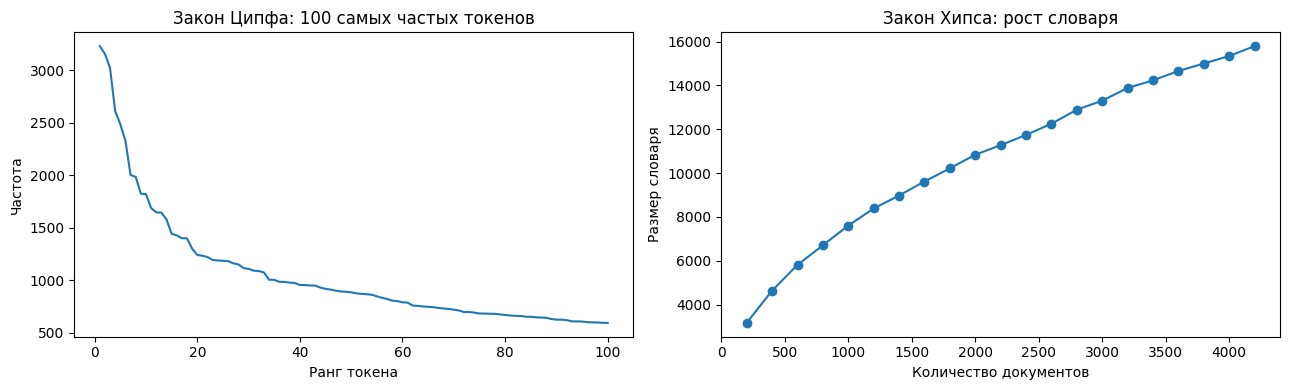

,Токен,Частота
0,работа,3229
1,документация,3156
2,проведение,3021
3,клиент,2611
4,составление,2486
5,учет,2327
6,товар,2002
7,документ,1985
8,продажа,1825
9,оформление,1820


In [14]:
corpus_counter = Counter()
documents_seen = []
vocabulary_sizes = []

for document_number, text in enumerate(x_train_processed, start=1):
    corpus_counter.update(text.split())

    # Фиксируем размер словаря через равные интервалы, чтобы увидеть его рост.
    if document_number % 200 == 0 or document_number == len(x_train_processed):
        documents_seen.append(document_number)
        vocabulary_sizes.append(len(corpus_counter))

most_common_tokens = corpus_counter.most_common(100)
zipf_frequencies = [frequency for _, frequency in most_common_tokens]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(1, 101), zipf_frequencies)
axes[0].set(
    title="Закон Ципфа: 100 самых частых токенов",
    xlabel="Ранг токена",
    ylabel="Частота",
)
axes[1].plot(documents_seen, vocabulary_sizes, marker="o")
axes[1].set(
    title="Закон Хипса: рост словаря",
    xlabel="Количество документов",
    ylabel="Размер словаря",
)
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(most_common_tokens[:15], columns=["Токен", "Частота"])
)

**Краткий вывод.** Частоты быстро убывают: небольшая группа слов
встречается тысячи раз, а большинство токенов значительно реже — это ожидаемая
картина закона Ципфа. График Хипса показывает, что словарь продолжает расти, но
каждая новая группа документов добавляет всё меньше новых слов.

### 7. Почему пунктуацию нельзя удалять автоматически

Чтобы изолировать роль пунктуации, временно возвращаемся к исходным текстам и
сравниваем два одинаковых TF-IDF-классификатора. Этот контролируемый эксперимент
не меняет подготовленные лемматизированные данные для заданий.

In [15]:
PUNCT_TOKEN_PATTERN = re.compile(r"\w+|[^\w\s]", re.UNICODE)


def tokenize_with_punctuation(text):
    '''Выделяет слова, числа и каждый знак пунктуации отдельно.'''
    return PUNCT_TOKEN_PATTERN.findall(text.lower())


punctuation_validation_vectorizer = TfidfVectorizer(
    tokenizer=tokenize_with_punctuation,
    token_pattern=None,
    lowercase=False,
    max_features=30_000,
)
punctuation_validation_fit = punctuation_validation_vectorizer.fit_transform(
    x_model_fit
)
punctuation_validation_data = punctuation_validation_vectorizer.transform(
    x_model_valid
)
punctuation_validation_model = LogisticRegression(
    max_iter=1000, random_state=RANDOM_STATE
)
punctuation_validation_model.fit(punctuation_validation_fit, y_model_fit)
punctuation_validation_prediction = punctuation_validation_model.predict(
    punctuation_validation_data
)
punctuation_validation_f1 = f1_score(
    y_model_valid, punctuation_validation_prediction, average="macro"
)

punctuation_vectorizer = TfidfVectorizer(
    tokenizer=tokenize_with_punctuation,
    token_pattern=None,
    lowercase=False,
    max_features=30_000,
)
punctuation_train = punctuation_vectorizer.fit_transform(x_train)
punctuation_test = punctuation_vectorizer.transform(x_test)
punctuation_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)
punctuation_model.fit(punctuation_train, y_train)
punctuation_prediction = punctuation_model.predict(punctuation_test)
punctuation_macro_f1 = f1_score(
    y_test, punctuation_prediction, average="macro"
)
if is_record_candidate(punctuation_validation_f1):
    register_tested_candidate(
        "LogisticRegression", "TF-IDF, токены с пунктуацией",
        punctuation_validation_f1, punctuation_macro_f1,
    )

punctuation_features = punctuation_vectorizer.get_feature_names_out()
punctuation_strength = np.abs(punctuation_model.coef_).max(axis=0)
punctuation_characters = set(punctuation) | {"«", "»", "—", "…"}
punctuation_rows = [
    {"Знак": feature, "Максимальный коэффициент": punctuation_strength[index]}
    for index, feature in enumerate(punctuation_features)
    if feature in punctuation_characters
]
punctuation_df = (
    pd.DataFrame(punctuation_rows)
    .sort_values("Максимальный коэффициент", ascending=False)
    .head(10)
)

print(
    f"Без пунктуации: Val={pre_tfidf_validation_f1:.3f} | "
    f"Test={pre_tfidf_macro_f1:.3f}"
)
print(
    f"С пунктуацией: Val={punctuation_validation_f1:.3f} | "
    f"Test={punctuation_macro_f1:.3f}"
)
display(
    punctuation_df.style.format(
        {"Максимальный коэффициент": "{:.3f}"}
    )
)

Без пунктуации: Val=0.844 | Test=0.801
С пунктуацией: Val=0.818 | Test=0.796


,Знак,Максимальный коэффициент
10,",",1.694
13,/,1.485
6,(,0.953
12,.,0.896
7,),0.834
1,"""",0.784
20,|,0.730
14,:,0.704
18,\,0.655
8,*,0.644


**Краткий вывод.** Сохранение пунктуации снизило Macro F1 с **0.801**
до **0.796**. Для этого набора знаки препинания не дали полезного сигнала, поэтому
обычная словесная токенизация подходит лучше.

### 8. Параметр analyzer и символьные n-граммы

Проверяем все строковые варианты CountVectorizer: word, char и char_wb.
Для word перебираем диапазоны (1,1), (1,2), (1,3), а для двух символьных
режимов — (1,1), (2,3), (3,5), (4,6), (5,7). Конфигурации сравниваются на
общей validation-части; новый глобальный рекорд сразу проверяется на тесте.

In [16]:
x_analyzer_fit, x_analyzer_valid = (
    x_model_fit_processed, x_model_valid_processed
)
y_analyzer_fit, y_analyzer_valid = y_model_fit, y_model_valid
analyzer_settings = [
    ("word", (1, 1)), ("word", (1, 2)), ("word", (1, 3)),
    ("char", (1, 1)), ("char", (2, 3)), ("char", (3, 5)),
    ("char", (4, 6)), ("char", (5, 7)),
    ("char_wb", (1, 1)), ("char_wb", (2, 3)), ("char_wb", (3, 5)),
    ("char_wb", (4, 6)), ("char_wb", (5, 7)),
]
analyzer_rows = []
for analyzer_name, ngram_range in analyzer_settings:
    started = time.perf_counter()
    vectorizer = CountVectorizer(
        analyzer=analyzer_name, ngram_range=ngram_range,
        min_df=2, max_features=40_000
    )
    fit_matrix = vectorizer.fit_transform(x_analyzer_fit)
    valid_matrix = vectorizer.transform(x_analyzer_valid)
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(fit_matrix, y_analyzer_fit)
    prediction = model.predict(valid_matrix)
    validation_f1 = f1_score(
        y_analyzer_valid, prediction, average="macro"
    )
    evaluate_logistic_candidate(
        "LogisticRegression",
        f"Count, analyzer={analyzer_name}, ngram={ngram_range}",
        validation_f1, CountVectorizer,
        {
            "analyzer": analyzer_name, "ngram_range": ngram_range,
            "min_df": 2, "max_features": 40_000,
        },
        x_train_processed, x_test_processed,
    )
    analyzer_rows.append(
        {
            "analyzer": analyzer_name,
            "ngram_range": ngram_range,
            "Validation Macro F1": validation_f1,
            "Число признаков": fit_matrix.shape[1],
            "Время, с": time.perf_counter() - started,
        }
    )

analyzer_results_df = pd.DataFrame(analyzer_rows).sort_values(
    "Validation Macro F1", ascending=False
).reset_index(drop=True)
best_analyzer = analyzer_results_df.loc[0, "analyzer"]
best_analyzer_ngram = analyzer_results_df.loc[0, "ngram_range"]
display(
    analyzer_results_df.style.format(
        {"Validation Macro F1": "{:.3f}", "Время, с": "{:.2f}"}
    )
)

,analyzer,ngram_range,Validation Macro F1,Число признаков,"Время, с"
0,word,"(1, 2)",0.840,37207,2.44
1,word,"(1, 3)",0.836,40000,3.87
2,char,"(3, 5)",0.816,40000,20.75
3,word,"(1, 1)",0.815,6962,0.83
4,char_wb,"(3, 5)",0.807,40000,19.86
5,char,"(4, 6)",0.806,40000,17.41
6,char_wb,"(5, 7)",0.805,40000,11.26
7,char,"(2, 3)",0.803,8674,17.00
8,char,"(5, 7)",0.802,40000,16.34
9,char_wb,"(4, 6)",0.801,40000,14.74


In [17]:
best_analyzer_vectorizer = CountVectorizer(
    analyzer=best_analyzer, ngram_range=best_analyzer_ngram,
    min_df=2, max_features=40_000
)
best_analyzer_train = best_analyzer_vectorizer.fit_transform(
    x_train_processed
)
best_analyzer_test = best_analyzer_vectorizer.transform(x_test_processed)
best_analyzer_model = LogisticRegression(
    max_iter=1000, random_state=RANDOM_STATE
)
best_analyzer_model.fit(best_analyzer_train, y_train)
best_analyzer_prediction = best_analyzer_model.predict(best_analyzer_test)
best_analyzer_test_f1 = f1_score(
    y_test, best_analyzer_prediction, average="macro"
)
print(
    f"Выбрано: analyzer='{best_analyzer}', "
    f"ngram_range={best_analyzer_ngram}"
)
print(f"Test Macro F1: {best_analyzer_test_f1:.3f}")

Выбрано: analyzer='word', ngram_range=(1, 2)
Test Macro F1: 0.795


**Краткий вывод.** Лучшей конфигурацией стал
analyzer='word' с ngram_range=(1, 2): Validation Macro F1 **0.840**.
Вариант word с диапазоном (1, 3) получил **0.836**. Лучшие символьные варианты:
char (3, 5) — **0.816**, char_wb (3, 5) — **0.807**. На финальном тесте
выбранная конфигурация получила Macro F1 **0.795**. Символьные n-граммы
не превзошли сочетание слов и биграмм.

## Переход к заданиям

Предобработка завершена. Для заданий используются выбранные в главе 5
лемматизированные тексты без пунктуации, числового шума и обычных стоп-слов.

## Исходный текст задания 1

## Задание 1.

**Задание**: обучите три классификатора:

1) на токенах с высокой частотой

2) на токенах со средней частотой

3) на токенах с низкой частотой

Сравните полученные результаты, оцените какие токены наиболее важные для классификации.

### Выполнение задания 1

Частоты считаются только по полностью обработанной обучающей выборке. Один и тот
же словарь делится на три группы; каждую группу сравниваем с Count и TF-IDF.

In [18]:
frequency_vectorizer = CountVectorizer(
    tokenizer=str.split, token_pattern=None, lowercase=False
)
x_train_all_tokens = frequency_vectorizer.fit_transform(x_train_processed)
token_names = frequency_vectorizer.get_feature_names_out()
token_frequencies = np.asarray(x_train_all_tokens.sum(axis=0)).ravel()
sorted_indices = np.argsort(token_frequencies, kind="stable")
low_idx, middle_idx, high_idx = np.array_split(sorted_indices, 3)
band_indices = {
    "Низкая частота": low_idx,
    "Средняя частота": middle_idx,
    "Высокая частота": high_idx,
}
band_vocabularies = {}
band_rows = []
for band_name, indices in band_indices.items():
    words = token_names[indices]
    frequencies = token_frequencies[indices]
    band_vocabularies[band_name] = words.tolist()
    band_rows.append(
        {
            "Группа": band_name,
            "Число токенов": len(words),
            "Минимальная частота": int(frequencies.min()),
            "Максимальная частота": int(frequencies.max()),
            "Примеры": ", ".join(words[:8]),
        }
    )
display(pd.DataFrame(band_rows).set_index("Группа"))

,Число токенов,Минимальная частота,Максимальная частота,Примеры
Группа,,,,
Низкая частота,5265,1,1,"aamp, abbyy, abcde, acceda, accounting, accruals, acd, acp"
Средняя частота,5265,1,4,"психоло, психологически, психологофизиологический, психопрофилактикапроведение, психор..."
Высокая частота,5265,4,3229,"выкуп, выпечка, выражение, выраженность, вырезка, высказывание, высоковольтный, высоко..."


In [19]:
frequency_results = []
frequency_models = {}
for representation_name, vectorizer_class in {
    "Count": CountVectorizer,
    "TF-IDF": TfidfVectorizer,
}.items():
    for band_name, vocabulary in band_vocabularies.items():
        parameters = {
            "vocabulary": vocabulary,
            "tokenizer": str.split,
            "token_pattern": None,
            "lowercase": False,
        }
        if representation_name == "TF-IDF":
            parameters["sublinear_tf"] = True
        validation_vectorizer = vectorizer_class(**parameters)
        validation_fit = validation_vectorizer.fit_transform(
            x_model_fit_processed
        )
        validation_data = validation_vectorizer.transform(
            x_model_valid_processed
        )
        validation_model = LogisticRegression(
            max_iter=1000, random_state=RANDOM_STATE
        )
        validation_model.fit(validation_fit, y_model_fit)
        validation_prediction = validation_model.predict(validation_data)
        validation_f1 = f1_score(
            y_model_valid, validation_prediction, average="macro"
        )
        vectorizer = vectorizer_class(**parameters)
        train_matrix = vectorizer.fit_transform(x_train_processed)
        test_matrix = vectorizer.transform(x_test_processed)
        model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
        model.fit(train_matrix, y_train)
        prediction = model.predict(test_matrix)
        test_f1 = f1_score(y_test, prediction, average="macro")
        if is_record_candidate(validation_f1):
            register_tested_candidate(
                "LogisticRegression",
                f"{representation_name}, {band_name.lower()}, Mystem",
                validation_f1, test_f1,
            )
        frequency_models[(representation_name, band_name)] = (
            vectorizer, model, prediction
        )
        frequency_results.append(
            {
                "Представление": representation_name,
                "Группа": band_name,
                "Validation Macro F1": validation_f1,
                "Accuracy": accuracy_score(y_test, prediction),
                "Macro F1": test_f1,
            }
        )
frequency_results_df = pd.DataFrame(frequency_results).sort_values(
    "Macro F1", ascending=False
)
display(
    frequency_results_df.style.format(
        {"Accuracy": "{:.3f}", "Macro F1": "{:.3f}"}
    )
)

,Представление,Группа,Validation Macro F1,Accuracy,Macro F1
5,TF-IDF,Высокая частота,0.858494,0.817,0.818
2,Count,Высокая частота,0.816099,0.784,0.786
4,TF-IDF,Средняя частота,0.302787,0.388,0.401
1,Count,Средняя частота,0.295986,0.386,0.398
0,Count,Низкая частота,0.047619,0.277,0.249
3,TF-IDF,Низкая частота,0.047619,0.275,0.247


### Краткий ответ к заданию 1

Macro F1 для Count: низкая группа — **0.249**, средняя — **0.398**, высокая —
**0.786**. Для TF-IDF: низкая — **0.247**, средняя — **0.401**, высокая —
**0.818**. Основной полезный сигнал находится в высокочастотной группе, а
TF-IDF улучшил её результат на **0.032** относительно Count.

Показатель по Test Macro F1 у TF-IDF+Высокочастотные токены наибольший. Но валидационная Macro F1 слабее на 0.03, поэтому эффект можно считать случайным и незначительным. Предпочтем оставить предыдущую лучшую модель `LogisticRegression + TF-IDF (1,2) + Mystem` со значением F1 Macro **0.816** на тестовой выборке и **0.861** на валидационной.

## Исходный текст задания 2

### Задание 2.

найти фичи с наибольшей значимостью, и вывести их

### Выполнение задания 2

Обучим логистическую регрессию на униграммах и биграммах TF-IDF. У каждого
признака модель хранит коэффициент для каждого класса. Большой положительный
коэффициент означает, что слово или пара слов особенно сильно склоняет модель
к этому классу.

In [20]:
task2_validation_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_features=40_000, sublinear_tf=True
)
task2_validation_fit = task2_validation_vectorizer.fit_transform(
    x_model_fit_processed
)
task2_validation_data = task2_validation_vectorizer.transform(
    x_model_valid_processed
)
task2_validation_model = LogisticRegression(
    max_iter=1000, random_state=RANDOM_STATE
)
task2_validation_model.fit(task2_validation_fit, y_model_fit)
task2_validation_prediction = task2_validation_model.predict(
    task2_validation_data
)
task2_validation_f1 = f1_score(
    y_model_valid, task2_validation_prediction, average="macro"
)

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_features=40_000, sublinear_tf=True
)
x_train_tfidf = tfidf_vectorizer.fit_transform(x_train_processed)
x_test_tfidf = tfidf_vectorizer.transform(x_test_processed)
tfidf_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
tfidf_model.fit(x_train_tfidf, y_train)
tfidf_prediction = tfidf_model.predict(x_test_tfidf)
tfidf_macro_f1 = f1_score(y_test, tfidf_prediction, average="macro")
if is_record_candidate(task2_validation_f1):
    register_tested_candidate(
        "LogisticRegression",
        "TF-IDF (1,2), все обработанные токены, Mystem",
        task2_validation_f1, tfidf_macro_f1,
    )
print(classification_report(y_test, tfidf_prediction, digits=3, zero_division=0))
print(f"Validation={task2_validation_f1:.3f} | Test={tfidf_macro_f1:.3f}")

Претендент: LogisticRegression | TF-IDF (1,2), все обработанные токены, Mystem | Val=0.862 | Test=0.815
                            precision    recall  f1-score   support

Медицина и здравоохранение      0.848     0.760     0.801       300
       Образование и наука      0.850     0.833     0.842       300
    Строительство и ремонт      0.909     0.833     0.870       300
        Торговля и продажи      0.694     0.800     0.743       300
     Транспорт и логистика      0.795     0.813     0.804       300
     Финансы и бухгалтерия      0.819     0.843     0.831       300

                  accuracy                          0.814      1800
                 macro avg      0.819     0.814     0.815      1800
              weighted avg      0.819     0.814     0.815      1800

Validation=0.862 | Test=0.815


In [21]:
# Для каждого класса выбираем признаки с самыми большими положительными коэффициентами.
feature_names = tfidf_vectorizer.get_feature_names_out()
top_features = {}
for class_index, class_name in enumerate(tfidf_model.classes_):
    best_indices = np.argsort(tfidf_model.coef_[class_index])[-10:][::-1]
    top_features[class_name] = feature_names[best_indices].tolist()
top_features_df = pd.DataFrame(top_features)
top_features_df.index = np.arange(1, len(top_features_df) + 1)
top_features_df.index.name = "Место"
display(top_features_df)

print("\nТри наиболее значимых признака по классам:")
for class_name, words in top_features.items():
    print(f"Класс «{class_name}»: {', '.join(words[:3])}")

,Медицина и здравоохранение,Образование и наука,Строительство и ремонт,Торговля и продажи,Транспорт и логистика,Финансы и бухгалтерия
Место,,,,,,
1,медицинский,ребенок,объект,продажа,автомобиль,бухгалтерский
2,пациент,учебный,строительство,товар,перевозка,банк
3,врач,занятие,строительный,покупатель,ремонт,учет
4,больной,образовательный,работа,магазин,груз,кредитный
5,лекарственный,родитель,проектный,торговый,склад,счет
6,лечение,обучение,заказчик,клиент,водитель,банковский
7,аптека,преподавание,проектирование,касса,транспортный,лицо
8,препарат,урок,монтаж,выкладка,доставка,налоговый
9,отделение,проведение,чертеж,закупка,транспорт,расчет



Три наиболее значимых признака по классам:
Класс «Медицина и здравоохранение»: медицинский, пациент, врач
Класс «Образование и наука»: ребенок, учебный, занятие
Класс «Строительство и ремонт»: объект, строительство, строительный
Класс «Торговля и продажи»: продажа, товар, покупатель
Класс «Транспорт и логистика»: автомобиль, перевозка, ремонт
Класс «Финансы и бухгалтерия»: бухгалтерский, банк, учет


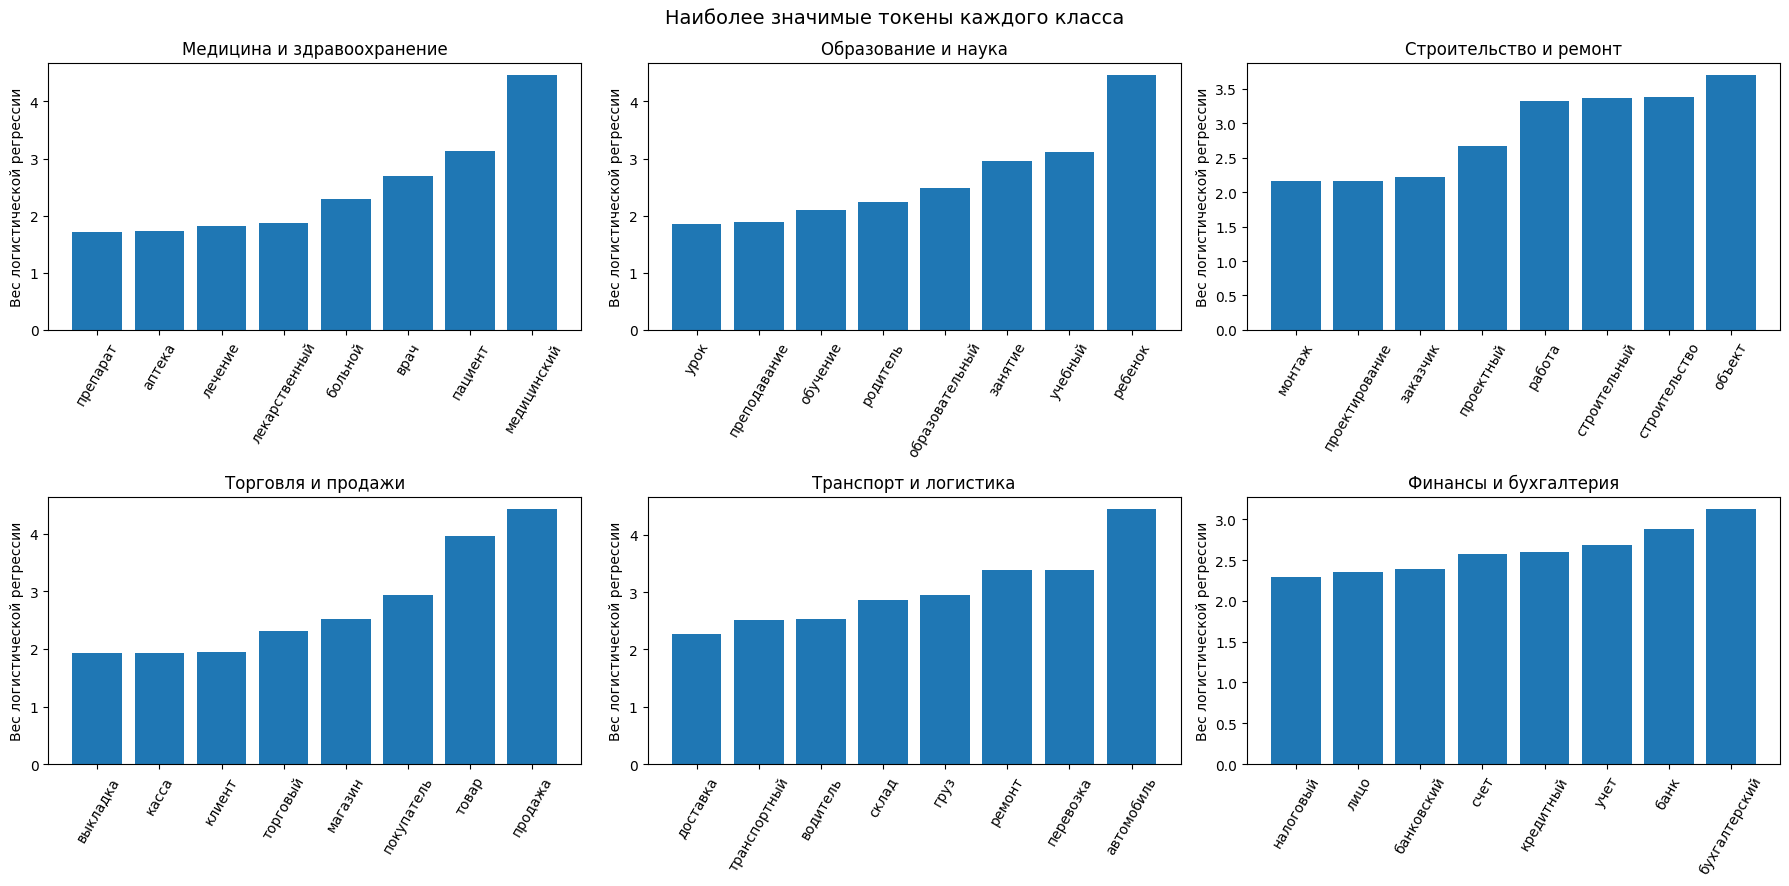

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
feature_names = tfidf_vectorizer.get_feature_names_out()
for class_index, (axis, class_name) in enumerate(
    zip(axes.ravel(), tfidf_model.classes_)
):
    class_weights = tfidf_model.coef_[class_index]
    top_indices = np.argsort(class_weights)[-8:]
    axis.bar(feature_names[top_indices], class_weights[top_indices])
    axis.set_title(class_name)
    axis.set_ylabel("Вес логистической регрессии")
    axis.tick_params(axis="x", rotation=60)
fig.suptitle("Наиболее значимые токены каждого класса", fontsize=14)
plt.tight_layout()
plt.show()

### Краткий ответ к заданию 2

TF-IDF с логистической регрессией получил Macro F1 **0.815**. Наибольшие веса
получили содержательные леммы: «медицинский», «пациент», «врач» для медицины;
«ребёнок», «учебный», «занятие» для образования; «объект», «строительство» для
строительства; «продажа», «товар» для торговли; «автомобиль», «перевозка» для
транспорта; «бухгалтерский», «банк», «учёт» для финансов. Отдельная диаграмма
показывает высоту коэффициента каждого токена для каждого класса.

## Исходный текст задания 3

### Задание 3.

1) сравнить count/tf-idf/hashing векторайзеры/полносвязанную сетку (построить classification_report)

2) подобрать оптимальный размер для hashing векторайзера

3) убедиться что для сетки нет переобучения

### Выполнение задания 3

Сравниваем методы на обработанных текстах. Время каждого линейного метода
включает собственные векторизацию, обучение и предсказание; заранее вычисленные
матрицы не переиспользуются.

In [23]:
classic_results = []


def evaluate_linear(name, vectorizer):
    validation_vectorizer = type(vectorizer)(**vectorizer.get_params())
    validation_fit = validation_vectorizer.fit_transform(x_model_fit_processed)
    validation_data = validation_vectorizer.transform(x_model_valid_processed)
    validation_model = LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE
    )
    validation_model.fit(validation_fit, y_model_fit)
    validation_prediction = validation_model.predict(validation_data)
    validation_f1 = f1_score(
        y_model_valid, validation_prediction, average="macro"
    )
    started = time.perf_counter()
    train_matrix = vectorizer.fit_transform(x_train_processed)
    test_matrix = vectorizer.transform(x_test_processed)
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(train_matrix, y_train)
    prediction = model.predict(test_matrix)
    elapsed = time.perf_counter() - started
    test_f1 = f1_score(y_test, prediction, average="macro")
    if is_record_candidate(validation_f1):
        register_tested_candidate(
            "LogisticRegression", name, validation_f1, test_f1
        )
    classic_results.append(
        {
            "Метод": name,
            "Validation Macro F1": validation_f1,
            "Macro F1": test_f1,
            "Время, с": elapsed,
        }
    )
    print(f"\n=== {name} ===")
    print(classification_report(y_test, prediction, digits=3, zero_division=0))
    return vectorizer, model, prediction


count_vectorizer = CountVectorizer(
    ngram_range=(1, 2), min_df=2, max_features=40_000
)
count_vectorizer, count_model, count_prediction = evaluate_linear(
    "Count + LogisticRegression", count_vectorizer
)
task3_tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2,
    max_features=40_000, sublinear_tf=True
)
(
    task3_tfidf_vectorizer,
    task3_tfidf_model,
    task3_tfidf_prediction,
) = evaluate_linear(
    "TF-IDF + LogisticRegression", task3_tfidf_vectorizer
)


=== Count + LogisticRegression ===
                            precision    recall  f1-score   support

Медицина и здравоохранение      0.772     0.780     0.776       300
       Образование и наука      0.858     0.803     0.830       300
    Строительство и ремонт      0.869     0.843     0.856       300
        Торговля и продажи      0.696     0.740     0.717       300
     Транспорт и логистика      0.764     0.777     0.770       300
     Финансы и бухгалтерия      0.817     0.820     0.819       300

                  accuracy                          0.794      1800
                 macro avg      0.796     0.794     0.795      1800
              weighted avg      0.796     0.794     0.795      1800




=== TF-IDF + LogisticRegression ===
                            precision    recall  f1-score   support

Медицина и здравоохранение      0.848     0.760     0.801       300
       Образование и наука      0.850     0.833     0.842       300
    Строительство и ремонт      0.909     0.833     0.870       300
        Торговля и продажи      0.694     0.800     0.743       300
     Транспорт и логистика      0.795     0.813     0.804       300
     Финансы и бухгалтерия      0.819     0.843     0.831       300

                  accuracy                          0.814      1800
                 macro avg      0.819     0.814     0.815      1800
              weighted avg      0.819     0.814     0.815      1800



### Подбор размера HashingVectorizer

`n_features` — длина итогового вектора. Слишком маленькое значение
создаёт много коллизий, а слишком большое требует больше памяти.

Размер выбирается по **валидационной выборке** — части обучающих
данных. Тест остаётся нетронутым до финальной оценки. Проверяем степени
двойки: 4096, 16384, 65536 и 262144.

In [24]:
x_subtrain, x_valid = x_model_fit_processed, x_model_valid_processed
y_subtrain, y_valid = y_model_fit, y_model_valid
hashing_candidates = [2**12, 2**14, 2**16, 2**18]
hashing_rows = []
for n_features in hashing_candidates:
    vectorizer = HashingVectorizer(
        n_features=n_features, alternate_sign=False,
        ngram_range=(1, 2), norm="l2"
    )
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(vectorizer.transform(x_subtrain), y_subtrain)
    valid_prediction = model.predict(vectorizer.transform(x_valid))
    validation_f1 = f1_score(y_valid, valid_prediction, average="macro")
    evaluate_logistic_candidate(
        "LogisticRegression", f"Hashing ({n_features}), Mystem",
        validation_f1, HashingVectorizer,
        {
            "n_features": n_features, "alternate_sign": False,
            "ngram_range": (1, 2), "norm": "l2",
        },
        x_train_processed, x_test_processed,
    )
    hashing_rows.append({
        "n_features": n_features,
        "Validation Macro F1": validation_f1,
    })
hashing_search_df = pd.DataFrame(hashing_rows).set_index("n_features")
best_hashing_size = int(hashing_search_df["Validation Macro F1"].idxmax())
display(hashing_search_df.style.format({"Validation Macro F1": "{:.3f}"}))
print(f"Выбран размер: {best_hashing_size}")

,Validation Macro F1
n_features,
4096,0.832
16384,0.843
65536,0.840
262144,0.841


Выбран размер: 16384


In [25]:
hashing_vectorizer = HashingVectorizer(
    n_features=best_hashing_size, alternate_sign=False,
    ngram_range=(1, 2), norm="l2"
)
hashing_vectorizer, hashing_model, hashing_prediction = evaluate_linear(
    f"Hashing ({best_hashing_size}) + LogisticRegression", hashing_vectorizer
)
display(
    pd.DataFrame(classic_results).set_index("Метод")
    .sort_values("Macro F1", ascending=False)
    .style.format({
            "Validation Macro F1": "{:.3f}",
            "Macro F1": "{:.3f}",
            "Время, с": "{:.2f}",
        })
)


=== Hashing (16384) + LogisticRegression ===
                            precision    recall  f1-score   support

Медицина и здравоохранение      0.788     0.770     0.779       300
       Образование и наука      0.847     0.810     0.828       300
    Строительство и ремонт      0.900     0.843     0.871       300
        Торговля и продажи      0.690     0.750     0.719       300
     Транспорт и логистика      0.779     0.787     0.783       300
     Финансы и бухгалтерия      0.800     0.827     0.813       300

                  accuracy                          0.798      1800
                 macro avg      0.801     0.798     0.799      1800
              weighted avg      0.801     0.798     0.799      1800



,Validation Macro F1,Macro F1,"Время, с"
Метод,,,
TF-IDF + LogisticRegression,0.862,0.815,3.18
Hashing (16384) + LogisticRegression,0.843,0.799,1.76
Count + LogisticRegression,0.840,0.795,3.27


### Полносвязная нейронная сеть на PyTorch

TF-IDF оставляет 6000 наиболее полезных признаков. Сеть получает эти
числа, пропускает их через скрытый слой из 128 нейронов и выдаёт
вероятности шести классов.

**Эпоха** — один полный проход по обучающим данным. После каждой эпохи
измеряем качество на валидации. Если оно не улучшается пять эпох,
обучение останавливается и возвращается лучшая версия сети.

**Переобучение** возникает, когда результат на обучении улучшается, а
на новых данных ухудшается. Графики позволяют это заметить.

In [26]:
torch.manual_seed(RANDOM_STATE)
torch.set_num_threads(min(4, max(1, torch.get_num_threads())))
x_nn_train = x_model_fit_processed
x_nn_valid = x_model_valid_processed
y_nn_train = y_model_fit
y_nn_valid = y_model_valid
nn_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_features=6000,
    sublinear_tf=True, dtype=np.float32
)
# Нейронная сеть принимает плотные числовые массивы, поэтому преобразуем TF-IDF-матрицы.
X_nn_train = nn_vectorizer.fit_transform(x_nn_train).toarray()
X_nn_valid = nn_vectorizer.transform(x_nn_valid).toarray()
X_nn_test = nn_vectorizer.transform(x_test_processed).toarray()
label_encoder = LabelEncoder()
y_nn_train_encoded = label_encoder.fit_transform(y_nn_train)
y_nn_valid_encoded = label_encoder.transform(y_nn_valid)
train_dataset = TensorDataset(
    torch.from_numpy(X_nn_train), torch.from_numpy(y_nn_train_encoded).long()
)
valid_x_tensor = torch.from_numpy(X_nn_valid)
valid_y_tensor = torch.from_numpy(y_nn_valid_encoded).long()
test_x_tensor = torch.from_numpy(X_nn_test)
train_loader = DataLoader(
    train_dataset, batch_size=128, shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_STATE)
)

In [27]:
# Простая полносвязная сеть: один скрытый слой и выход по числу классов.
class ResumeNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size), nn.ReLU(),
            nn.Dropout(0.25), nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.layers(x)


network = ResumeNet(X_nn_train.shape[1], 128, len(label_encoder.classes_))
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(network.parameters(), lr=1e-3, weight_decay=1e-4)
train_losses, valid_losses, valid_f1_scores = [], [], []
best_valid_f1, best_state, best_epoch = -1.0, None, 0
patience, epochs_without_improvement, max_epochs = 5, 0, 30
torch_started = time.perf_counter()

for epoch in range(1, max_epochs + 1):
    # На обучающем шаге обновляем веса сети по небольшим пакетам данных.
    network.train()
    total_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        logits = network(batch_x)
        loss = loss_function(logits, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch_x)
    train_loss = total_loss / len(train_dataset)

    # На валидации веса не меняются: оцениваем способность работать с новыми данными.
    network.eval()
    with torch.no_grad():
        valid_logits = network(valid_x_tensor)
        valid_loss = loss_function(valid_logits, valid_y_tensor).item()
        valid_prediction = valid_logits.argmax(dim=1).numpy()
        valid_f1 = f1_score(y_nn_valid_encoded, valid_prediction, average="macro")
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    valid_f1_scores.append(valid_f1)
    print(
        f"Эпоха {epoch:02d}: train loss={train_loss:.4f}, "
        f"valid loss={valid_loss:.4f}, valid macro F1={valid_f1:.3f}"
    )
    if valid_f1 > best_valid_f1 + 1e-4:
        best_valid_f1, best_epoch = valid_f1, epoch
        best_state = copy.deepcopy(network.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print("Ранняя остановка: качество валидации больше не улучшается.")
            break

torch_seconds = time.perf_counter() - torch_started
network.load_state_dict(best_state)
network.eval()
with torch.no_grad():
    torch_test_encoded = network(test_x_tensor).argmax(dim=1).numpy()
torch_prediction = label_encoder.inverse_transform(torch_test_encoded)
torch_macro_f1 = f1_score(y_test, torch_prediction, average="macro")
if is_record_candidate(best_valid_f1):
    register_tested_candidate(
        "ResumeNet",
        "TF-IDF (1,2), 6000 признаков, Mystem",
        best_valid_f1,
        torch_macro_f1,
    )
print("\n=== Полносвязная сеть PyTorch ===")
print(classification_report(y_test, torch_prediction, digits=3, zero_division=0))
print(f"Эпоха={best_epoch} | Val={best_valid_f1:.3f} | Test={torch_macro_f1:.3f}")

Эпоха 01: train loss=1.7131, valid loss=1.5690, valid macro F1=0.776


Эпоха 02: train loss=1.3710, valid loss=1.1574, valid macro F1=0.824


Эпоха 03: train loss=0.9370, valid loss=0.7967, valid macro F1=0.841


Эпоха 04: train loss=0.6378, valid loss=0.6181, valid macro F1=0.854


Эпоха 05: train loss=0.4794, valid loss=0.5436, valid macro F1=0.854


...

Эпоха 09: train loss=0.2346, valid loss=0.4770, valid macro F1=0.855


Эпоха 10: train loss=0.1940, valid loss=0.4762, valid macro F1=0.852


Эпоха 11: train loss=0.1635, valid loss=0.4759, valid macro F1=0.848


Эпоха 12: train loss=0.1383, valid loss=0.4797, valid macro F1=0.850


Эпоха 13: train loss=0.1148, valid loss=0.4834, valid macro F1=0.849
Ранняя остановка: качество валидации больше не улучшается.

=== Полносвязная сеть PyTorch ===
                            precision    recall  f1-score   support

Медицина и здравоохранение      0.819     0.767     0.792       300
       Образование и наука      0.834     0.840     0.837       300
    Строительство и ремонт      0.904     0.847     0.874       300
        Торговля и продажи      0.723     0.783     0.752       300
     Транспорт и логистика      0.794     0.820     0.807       300
     Финансы и бухгалтерия      0.824     0.827     0.825       300

                  accuracy                          0.814      1800
                 macro avg      0.816     0.814     0.815      1800
              weighted avg      0.816     0.814     0.815      1800

Эпоха=8 | Val=0.856 | Test=0.815


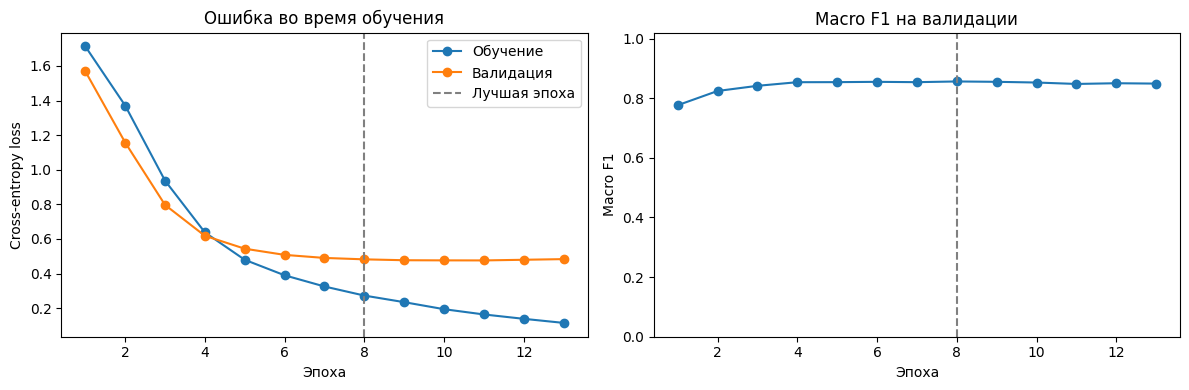

Явного устойчивого ухудшения валидации не обнаружено; дополнительно применена ранняя остановка.


In [28]:
epochs = np.arange(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, train_losses, marker="o", label="Обучение")
axes[0].plot(epochs, valid_losses, marker="o", label="Валидация")
axes[0].axvline(best_epoch, color="grey", linestyle="--", label="Лучшая эпоха")
axes[0].set(title="Ошибка во время обучения", xlabel="Эпоха", ylabel="Cross-entropy loss")
axes[0].legend()
axes[1].plot(epochs, valid_f1_scores, marker="o")
axes[1].axvline(best_epoch, color="grey", linestyle="--")
axes[1].set(title="Macro F1 на валидации", xlabel="Эпоха", ylabel="Macro F1", ylim=(0, 1.02))
plt.tight_layout()
plt.show()

overfit_detected = (
    best_epoch < len(valid_losses) - 1
    and valid_losses[-1] > min(valid_losses) * 1.10
)
overfit_text = (
    "К концу обучения заметен рост validation loss; ранняя остановка вернула лучшую модель."
    if overfit_detected else
    "Явного устойчивого ухудшения валидации не обнаружено; "
    "дополнительно применена ранняя остановка."
)
print(overfit_text)

### Итоговое сравнение

Все строки используют одну validation-часть и один тестовый набор из 1800
резюме. Глобальный победитель последовательно обновил сначала validation-рекорд,
а затем тестовый рекорд.

In [29]:
final_rows = classic_results + [{
    "Метод": "Полносвязная сеть PyTorch",
    "Validation Macro F1": best_valid_f1,
    "Test Macro F1": torch_macro_f1,
    "Время, с": torch_seconds,
}]

final_results_df = (
    pd.DataFrame(final_rows).set_index("Метод")
    .sort_values("Test Macro F1", ascending=False)
)
display(final_results_df.style.format({
    "Validation Macro F1": "{:.3f}",
    "Test Macro F1": "{:.3f}",
    "Время, с": "{:.2f}",
}))
print(
    f"Лучшая: {best_model_name} | {best_model_strategy} | "
    f"Val={best_model_validation_f1:.3f} | Test={best_test_f1:.3f}"
)

,Validation Macro F1,Macro F1,"Время, с",Test Macro F1
Метод,,,,
Полносвязная сеть PyTorch,0.856,nan,5.47,0.815
Count + LogisticRegression,0.840,0.794678,3.27,nan
TF-IDF + LogisticRegression,0.862,0.815097,3.18,nan
Hashing (16384) + LogisticRegression,0.843,0.798776,1.76,nan


Лучшая: LogisticRegression | TF-IDF (1,2), лемматизация Mystem | Val=0.861 | Test=0.816


### Краткий ответ к заданию 3

Таблица сравнивает Count, TF-IDF, Hashing и полносвязную сеть на одинаковых
validation/test частях. Размер Hashing выбран только по validation, а ранняя
остановка вернула веса лучшей validation-эпохи нейросети.

## Общий вывод

Последовательная очистка и лемматизация улучшили представление текстов. Словарь
общих слов выбран на внутренней validation, а сравнение трёх лемматизаторов
определило основной способ обработки для последующих заданий.

Во всех модельных главах действует единое правило: только новый рекорд
Validation Macro F1 становится претендентом и проверяется на тесте; текущим
лидером он объявляется только после обновления Test Macro F1. Краткие строки
`Лучшая` показывают модель, стратегию и обе метрики.